# 21-cm Signal from PBH Dynamical Friction

## Preamble

In [514]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [515]:
%autoreload 

import sys
sys.path.append('../../')

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

import twenty_one
import fluctuations


In [516]:
%matplotlib inline

In [535]:
data = np.load('../../data/PBH_dynamical_friction/PBH/TGASVC.npz') 
# data = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/TGASONE.npz')

In [536]:
# Tk_ary has dimensions mPBH x fPBH x vPBH x z 
Tk_ary = data['TGAS']
v_ary = data['vPBH']
z_ary = data['z']
print(data['mPBH'])
print(data['fPBH'])
print(z_ary.shape)
print(v_ary.shape)
print(Tk_ary.shape)
print(v_ary)


[1000. 5000.]
[0.01 0.05 0.1  1.  ]
(10000,)
(100,)
(2, 4, 100, 10000)
[  0.1          1.10909091   2.11818182   3.12727273   4.13636364
   5.14545455   6.15454545   7.16363636   8.17272727   9.18181818
  10.19090909  11.2         12.20909091  13.21818182  14.22727273
  15.23636364  16.24545455  17.25454545  18.26363636  19.27272727
  20.28181818  21.29090909  22.3         23.30909091  24.31818182
  25.32727273  26.33636364  27.34545455  28.35454545  29.36363636
  30.37272727  31.38181818  32.39090909  33.4         34.40909091
  35.41818182  36.42727273  37.43636364  38.44545455  39.45454545
  40.46363636  41.47272727  42.48181818  43.49090909  44.5
  45.50909091  46.51818182  47.52727273  48.53636364  49.54545455
  50.55454545  51.56363636  52.57272727  53.58181818  54.59090909
  55.6         56.60909091  57.61818182  58.62727273  59.63636364
  60.64545455  61.65454545  62.66363636  63.67272727  64.68181818
  65.69090909  66.7         67.70909091  68.71818182  69.72727273
  70.7363636

In [519]:

z_xA_ary = np.arange(9, 31)
# 140 x z_xA_ary
xA_data = loadmat('../../data/xA_astromodel.mat')['xout']

In [520]:
xA_zeus = np.loadtxt('../../data/PBH_dynamical_friction/xA_zeus_default.txt')

xA_z_17 = np.interp(17, xA_zeus[:,0], xA_zeus[:,1])

Text(0, 0.5, '$x_\\alpha$')

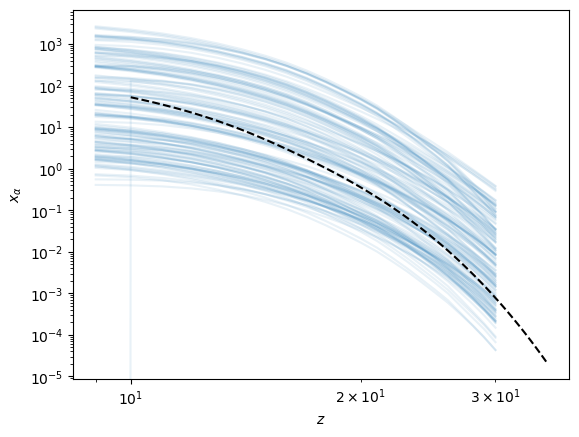

In [521]:
plt.figure() 

for xA_ary in xA_data: 

    plt.loglog(z_xA_ary, xA_ary, color='C0', alpha=0.1)

plt.loglog(xA_zeus[:, 0], xA_zeus[:, 1], color='k', ls='--', label='Zeus')

plt.xlabel(r'$z$')
plt.ylabel(r'$x_\alpha$')



(0.1, 10)

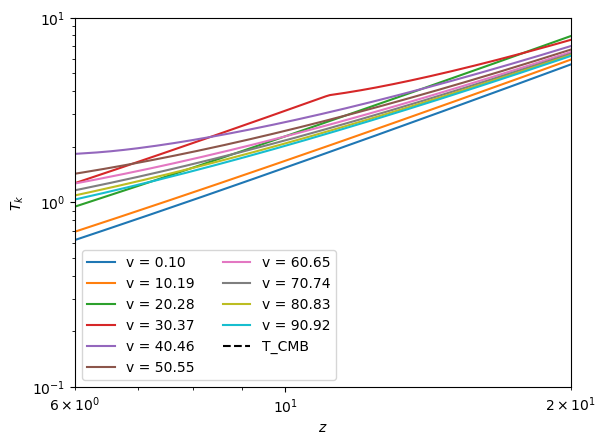

In [522]:
i = 0
j = -2

for k in np.arange(100): 
    if k % 10 == 0:
        plt.loglog(z_ary, Tk_ary[i,j,k,:], label='v = {:.2f}'.format(v_ary[k]))

plt.plot(z_ary, 2.725*(1+z_ary), color='k', ls='--', label='T_CMB')

plt.xlabel(r'$z$')
plt.ylabel(r'$T_k$')

plt.legend(ncol=2)

plt.xlim(6, 20)
plt.ylim(1e-1, 10)

Tk_fin_ary shape:  (2, 4, 100, 229)


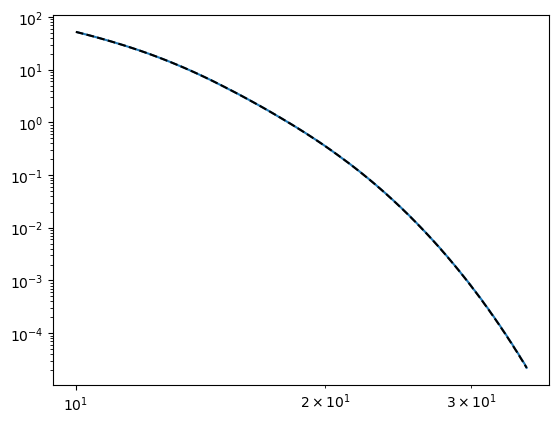

In [523]:
# Truncate the T_K data down to 10 < z < 30. 

z_fin_ary = z_ary[(z_ary < xA_zeus[-1,0]) & (z_ary > xA_zeus[0,0])]
Tk_fin_ary = Tk_ary[:, :, :, (z_ary < xA_zeus[-1,0]) & (z_ary > xA_zeus[0,0])]
xA_fin_ary = np.interp(z_fin_ary, xA_zeus[:, 0], xA_zeus[:, 1])

plt.figure()

plt.loglog(z_fin_ary, xA_fin_ary, color='C0', label=r'$x_\alpha$')
plt.loglog(xA_zeus[:,0], xA_zeus[:, 1], color='k', ls='--', label='Zeus')

print('Tk_fin_ary shape: ', Tk_fin_ary.shape)

In [524]:
# PBH mPBH x fPBH x vPBH x z 
T21_ary = twenty_one.T21(z_fin_ary, xA_fin_ary, Tk_fin_ary, TS_equal_Tb=False)

# Transpose to v_ary first, so that it becomes vPBH x mPBH x fPBH x z
T21_ary = T21_ary.transpose(2, 0, 1, 3) 

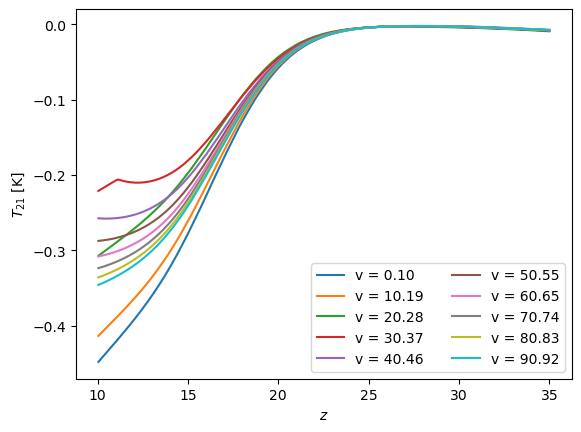

In [525]:

for k in np.arange(100): 
    if k % 10 == 0:
        plt.plot(z_fin_ary, T21_ary[k,i,j,:], label='v = {:.2f}'.format(v_ary[k]))

plt.xlabel(r'$z$')
plt.ylabel(r'$T_{21}$ [K]')
plt.legend(ncol=2)

In [532]:
# Focus in only on z = 17. 
z_17_idx = np.abs(z_fin_ary - 15).argmin()
T21_z_17_ary = T21_ary[:, :, :, z_17_idx]
# vPBH x mPBH x fPBH
print('T21_z_17_ary shape: ', T21_z_17_ary.shape)
T21_z_17_ary[np.isnan(T21_z_17_ary)] = 0.
# print(T21_z_17_ary)

T21_z_17_ary shape:  (100, 2, 4)


In [527]:
T21_fluc = fluctuations.Fluctuations(v_ary, T21_z_17_ary)

In [528]:
_ = T21_fluc.Delta2_f()

k_ary, xi_fft_ary = T21_fluc.power_spec 

PBH mass is:  1000.0
fPBH is:  0.01


(0.1, 10000.0)

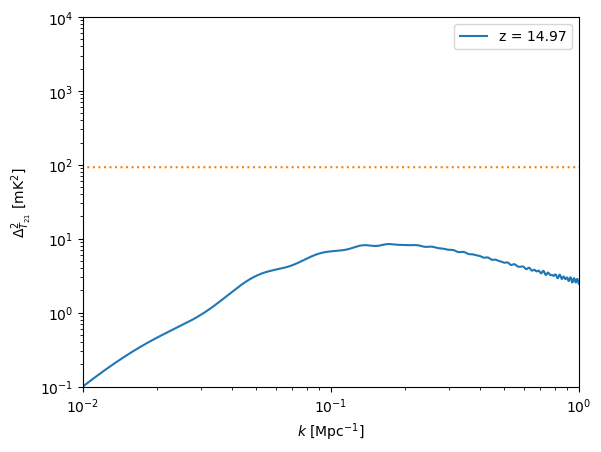

In [530]:
plt.figure()

plt.loglog()

# 600: z = 15.59
# 700: z = 13.18

i = 0
j = -4
print('PBH mass is: ', data['mPBH'][i]) 
print('fPBH is: ', data['fPBH'][j])

plt.plot(k_ary, xi_fft_ary[:,i,j]*1e6, label=f'z = {z_fin_ary[z_17_idx]:.2f}')
plt.plot(k_ary, 92.7*np.ones_like(k_ary), ':')

plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$\Delta_{T_{21}}^2$ [mK$^{2}$]')

plt.legend(ncol=2)

plt.xlim(1e-2, 1)
plt.ylim(1e-1, 1e4)

In [531]:
# np.savez('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_D.npz', k_ary=k_ary, mPBH_ary=data['mPBH'], fPBH_ary=data['fPBH'], xi_fft_ary=xi_fft_ary)